# Feature: Pressure Distribution Entropy During Mid-Stance

## Concept
**Mid-stance** is the phase of the gait cycle where the body weight passes directly over the planted foot — the middle third of the stance phase. Gravel, cobblestone and brick create irregular, step-to-step variable loading patterns across the 12 zones — their entropy will be high and variable. Concrete and smooth asphalt will be low and consistent. This feature distinguishes surfaces that might feel similarly hard (concrete vs cobblestone) but differ in texture.*

### Two metrics extracted
| Metric | What it captures | Expected pattern |
|---|---|---|
| **H_spatial** (Shannon entropy) | How evenly pressure is spread across the 12 sensors | Higher on smooth surfaces (all sensors engaged uniformly) |
| **CV_spatial** (Coeff. of Variation) | How unevenly individual sensors are loaded vs. the mean | Higher on irregular surfaces (some zones overloaded, some idle) |

### Sensor Layout (Stappone Manual §3.3)
```
Forefoot  : P01, P02, P05, P06, P09, P12
Midfoot   : P03, P04, P07
Hindfoot  : P08, P10, P11
sole_id=1 → RIGHT foot  |  sole_id=2 → LEFT foot
Time resolution: 4 ms/sample  |  Pressure: 0–1023 (10-bit)
```

### Pipeline
```
Load CSVs → Filter corrupt rows → Compute total pressure
    ↓
Detect stance phases (threshold = p15 of signal per recording)
    ↓
Extract mid-stance = samples [33%–67%] of each stance window
    ↓
Compute H_spatial & CV_spatial per step
    ↓
Visualise → Line plot + Box plots → Statistical tests
```

## Cell 1 — Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import entropy as scipy_entropy, kruskal, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✓ Libraries loaded')

✓ Libraries loaded


## Cell 2 — Configuration

In [2]:
# ── Sensor columns ────────────────────────────────────────────────────────────
PRESSURE_COLS    = [f'pressure_{i:02d}' for i in range(1, 13)]
FOREFOOT_SENSORS = ['pressure_01','pressure_02','pressure_05',
                    'pressure_06','pressure_09','pressure_12']
MIDFOOT_SENSORS  = ['pressure_03','pressure_04','pressure_07']
HINDFOOT_SENSORS = ['pressure_08','pressure_10','pressure_11']

# ── Recording parameters ─────────────────────────────────────────────────────
SAMPLE_RATE_MS   = 4     # 4 ms per sample

# ── Stance detection ─────────────────────────────────────────────────────────
# The signal stays high (3000-4800 raw) during stance and dips toward swing/toe-off.
# We threshold at the 15th percentile of each recording to separate swing troughs
# from loaded stance — this adapts to each subject/surface automatically.
STANCE_PERCENTILE = 15   # signal >= p15 → in stance
MIN_STANCE_SAMP   = 20   # ~80 ms minimum
MAX_STANCE_SAMP   = 500  # ~2000 ms maximum

# ── Mid-stance window ─────────────────────────────────────────────────────────
MS_START = 1/3
MS_END   = 2/3

# ── Aesthetics ────────────────────────────────────────────────────────────────
SURFACE_COLORS = {'Brick': '#E07B39', 'Grass': '#4CAF50', 'Concrete': '#607D8B'}
DATA_PATHS     = {'Brick': 'data2/brick_dry.csv',
                  'Grass': 'data2/grass_dry.csv',
                  'Concrete': 'data2/concrete_dry.csv'}

print('Configuration ready.')
print(f'  Pressure columns : {PRESSURE_COLS}')
print(f'  Stance threshold : p{STANCE_PERCENTILE} of each recording')
print(f'  Mid-stance window: {MS_START:.0%}–{MS_END:.0%} of stance duration')

Configuration ready.
  Pressure columns : ['pressure_01', 'pressure_02', 'pressure_03', 'pressure_04', 'pressure_05', 'pressure_06', 'pressure_07', 'pressure_08', 'pressure_09', 'pressure_10', 'pressure_11', 'pressure_12']
  Stance threshold : p15 of each recording
  Mid-stance window: 33%–67% of stance duration


## Cell 3 — Load & Clean Data

In [3]:
raw = {}
for surface, path in DATA_PATHS.items():
    df = pd.read_csv(path, low_memory=False)
    before = len(df)
    df = df[df['corrupt'] == 0].copy()
    df['total_pressure'] = df[PRESSURE_COLS].sum(axis=1)
    df.reset_index(drop=True, inplace=True)
    raw[surface] = df
    print(f'{surface:>10}: {len(df):>5} rows  ({before-len(df)} corrupt removed) | '
          f'soles: {sorted(df.sole_id.unique())} | '
          f'pressure range: {df.total_pressure.min():.0f}–{df.total_pressure.max():.0f}')

     Brick:  2940 rows  (0 corrupt removed) | soles: [1, 2] | pressure range: 2786–5389
     Grass:  2979 rows  (0 corrupt removed) | soles: [1, 2] | pressure range: 2845–5489
  Concrete:  4349 rows  (0 corrupt removed) | soles: [1, 2] | pressure range: 2759–5391


## Cell 4 — Stance Phase Detection

The total pressure signal oscillates between:
- **~2900–3100 raw units** during swing/toe-off (foot lightly loaded or airborne)
- **~4300–4800 raw units** during mid-stance (full body weight)

We threshold at the **15th percentile** of each recording to adaptively separate stance from swing phases.

In [4]:
def detect_stance_windows(sdf,
                           stance_pct=STANCE_PERCENTILE,
                           min_samp=MIN_STANCE_SAMP,
                           max_samp=MAX_STANCE_SAMP):
    """
    Detect stance phases from a single-sole DataFrame.

    Strategy: signal >= p{stance_pct} → foot is in stance.
    Consecutive in-stance samples form a window; filter by
    plausible gait duration.

    Returns
    -------
    (windows, threshold)
    windows : list of dicts with 'start', 'end', 'duration' (in samples)
    threshold : adaptive threshold value used
    """
    sig = sdf['total_pressure'].values
    threshold = np.percentile(sig, stance_pct)
    in_stance = sig >= threshold

    windows = []
    i = 0
    while i < len(in_stance):
        if in_stance[i]:
            start = i
            while i < len(in_stance) and in_stance[i]:
                i += 1
            end = i
            dur = end - start
            if min_samp <= dur <= max_samp:
                windows.append({'start': start, 'end': end, 'duration': dur})
        else:
            i += 1
    return windows, threshold


# Run detection on all surface × sole combinations
stance_data = {}  # key: (surface, sole_id) → (sole_df, windows, threshold)

for surface, df in raw.items():
    for sole_id in sorted(df['sole_id'].unique()):
        sdf = df[df['sole_id'] == sole_id].reset_index(drop=True)
        wins, thr = detect_stance_windows(sdf)
        stance_data[(surface, sole_id)] = (sdf, wins, thr)
        foot = 'RIGHT' if sole_id == 1 else 'LEFT'
        durs = [w['duration'] for w in wins]
        print(f'{surface:>10} | {foot}: {len(wins):>3} stances detected '
              f'(threshold={thr:.0f}, '
              f'mean dur={np.mean(durs):.0f} samp = {np.mean(durs)*SAMPLE_RATE_MS:.0f} ms)')

     Brick | RIGHT:  23 stances detected (threshold=3027, mean dur=53 samp = 213 ms)
     Brick | LEFT:  23 stances detected (threshold=3508, mean dur=53 samp = 210 ms)
     Grass | RIGHT:  22 stances detected (threshold=3072, mean dur=55 samp = 220 ms)
     Grass | LEFT:  21 stances detected (threshold=3576, mean dur=57 samp = 228 ms)
  Concrete | RIGHT:  31 stances detected (threshold=3040, mean dur=58 samp = 231 ms)
  Concrete | LEFT:  30 stances detected (threshold=3463, mean dur=60 samp = 240 ms)


## Cell 5 — Mid-Stance Feature Extraction

For each detected stance window:
1. **Mid-stance slice** = samples at 33%–67% of stance duration
2. **Mean sensor values** = average each of the 12 channels across the slice
3. **H_spatial** = Shannon entropy of the normalised 12-channel distribution
   - `H = -Σ pᵢ log₂(pᵢ)`, where `pᵢ = mean_sensor_i / total`
   - Max possible = log₂(12) ≈ 3.585 bits (all sensors equal)
4. **CV_spatial** = std(sensor means) / mean(sensor means) — coefficient of variation
   - Captures how *unevenly* sensors are loaded
   - Higher on irregular surfaces where some zones are overloaded

In [5]:
def compute_midstance_features(sdf, wins,
                                ms_start=MS_START, ms_end=MS_END):
    """
    Extract mid-stance features from each detected stance window.

    Parameters
    ----------
    sdf   : DataFrame — single-sole data
    wins  : list of stance window dicts

    Returns
    -------
    DataFrame with per-step features
    """
    records = []
    for step_idx, win in enumerate(wins):
        s, e, d = win['start'], win['end'], win['duration']

        # Mid-stance slice
        ms_s = s + int(d * ms_start)
        ms_e = s + int(d * ms_end)
        if ms_e <= ms_s:
            continue

        ms_slice = sdf.iloc[ms_s:ms_e]

        # Mean pressure per sensor during mid-stance
        mp = ms_slice[PRESSURE_COLS].mean().values.astype(float)
        total = mp.sum()
        if total < 10:
            continue

        # ── Feature 1: Spatial Shannon Entropy ───────────────────────────────
        p_norm = np.clip(mp / total, 1e-10, 1.0)
        H_spatial = scipy_entropy(p_norm, base=2)  # bits; max = log2(12) ≈ 3.585

        # ── Feature 2: Spatial Coefficient of Variation ───────────────────────
        # How uneven is the loading across sensors?
        cv_spatial = mp.std() / (mp.mean() + 1e-10)

        # ── Mid-stance centre timestamp ───────────────────────────────────────
        centre_row = sdf.iloc[(ms_s + ms_e) // 2]

        records.append({
            'step_idx':          step_idx,
            'stance_start':      s,
            'stance_end':        e,
            'stance_dur_samp':   d,
            'stance_dur_ms':     d * SAMPLE_RATE_MS,
            'ms_start_idx':      ms_s,
            'ms_end_idx':        ms_e,
            'ms_centre_ts':      int(centre_row['timestamp']),
            'H_spatial':         H_spatial,
            'cv_spatial':        cv_spatial,
            'total_pressure_ms': total,
            **{f'mean_{col}': float(v) for col, v in zip(PRESSURE_COLS, mp)}
        })

    return pd.DataFrame(records)


# Run feature extraction
feature_results = {}  # key: (surface, sole_id) → feature DataFrame
all_rows = []

for (surface, sole_id), (sdf, wins, thr) in stance_data.items():
    feat_df = compute_midstance_features(sdf, wins)
    feat_df['surface'] = surface
    feat_df['sole_id'] = sole_id
    feat_df['foot']    = 'RIGHT' if sole_id == 1 else 'LEFT'
    feature_results[(surface, sole_id)] = feat_df
    all_rows.append(feat_df)

    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    print(f'{surface:>10} | {foot}: '
          f'n={len(feat_df):>3} steps | '
          f'H_spatial={feat_df.H_spatial.mean():.4f} ± {feat_df.H_spatial.std():.4f} bits | '
          f'CV_spatial={feat_df.cv_spatial.mean():.4f} ± {feat_df.cv_spatial.std():.4f}')

all_features = pd.concat(all_rows, ignore_index=True)
print(f'\nTotal steps: {len(all_features)}')

     Brick | RIGHT: n= 23 steps | H_spatial=3.5435 ± 0.0126 bits | CV_spatial=0.2376 ± 0.0380
     Brick | LEFT: n= 23 steps | H_spatial=3.5400 ± 0.0117 bits | CV_spatial=0.2470 ± 0.0254
     Grass | RIGHT: n= 22 steps | H_spatial=3.5481 ± 0.0111 bits | CV_spatial=0.2240 ± 0.0355
     Grass | LEFT: n= 21 steps | H_spatial=3.5432 ± 0.0058 bits | CV_spatial=0.2402 ± 0.0174
  Concrete | RIGHT: n= 31 steps | H_spatial=3.5428 ± 0.0146 bits | CV_spatial=0.2383 ± 0.0426
  Concrete | LEFT: n= 30 steps | H_spatial=3.5505 ± 0.0037 bits | CV_spatial=0.2197 ± 0.0118

Total steps: 150


## Cell 6 — Summary Statistics Table

In [6]:
MAX_ENTROPY = np.log2(12)  # ≈ 3.585 bits

summary_rows = []
for surface in ['Brick', 'Grass', 'Concrete']:
    sub = all_features[all_features['surface'] == surface]
    for feat_col, feat_name in [('H_spatial', 'H_spatial (bits)'), ('cv_spatial', 'CV_spatial')]:
        v = sub[feat_col].dropna().values
        summary_rows.append({
            'Surface': surface,
            'Feature': feat_name,
            'n_steps': len(v),
            'mean':   np.mean(v),
            'median': np.median(v),
            'std':    np.std(v),
            'IQR':    np.percentile(v,75) - np.percentile(v,25),
            'min':    np.min(v),
            'max':    np.max(v),
        })

summary = pd.DataFrame(summary_rows).round(5)
print('=== Mid-Stance Feature Summary (Both Feet) ===')
print(summary.to_string(index=False))
print(f'\nNote: Max possible H_spatial = log₂(12) = {MAX_ENTROPY:.4f} bits (all sensors equal)')
print('      CV_spatial: higher = more uneven sensor loading (texture effect)')

=== Mid-Stance Feature Summary (Both Feet) ===
 Surface          Feature  n_steps    mean  median     std     IQR     min     max
   Brick H_spatial (bits)       46 3.54177 3.54207 0.01202 0.00932 3.49663 3.56287
   Brick       CV_spatial       46 0.24230 0.24479 0.03196 0.02836 0.17588 0.33971
   Grass H_spatial (bits)       43 3.54569 3.54315 0.00905 0.01302 3.53264 3.56734
   Grass       CV_spatial       43 0.23192 0.24112 0.02864 0.04115 0.15677 0.27023
Concrete H_spatial (bits)       61 3.54658 3.54975 0.01123 0.00934 3.51485 3.56361
Concrete       CV_spatial       61 0.22915 0.22204 0.03234 0.02920 0.17018 0.31261

Note: Max possible H_spatial = log₂(12) = 3.5850 bits (all sensors equal)
      CV_spatial: higher = more uneven sensor loading (texture effect)


## Cell 7 — Line Plot: Total Pressure Signal with Mid-Stance Regions Marked

Shows the raw total pressure signal over a representative window of steps. The **light shaded region** covers the full stance phase; the **darker band** marks the mid-stance window. Shannon entropy and CV are annotated per step.

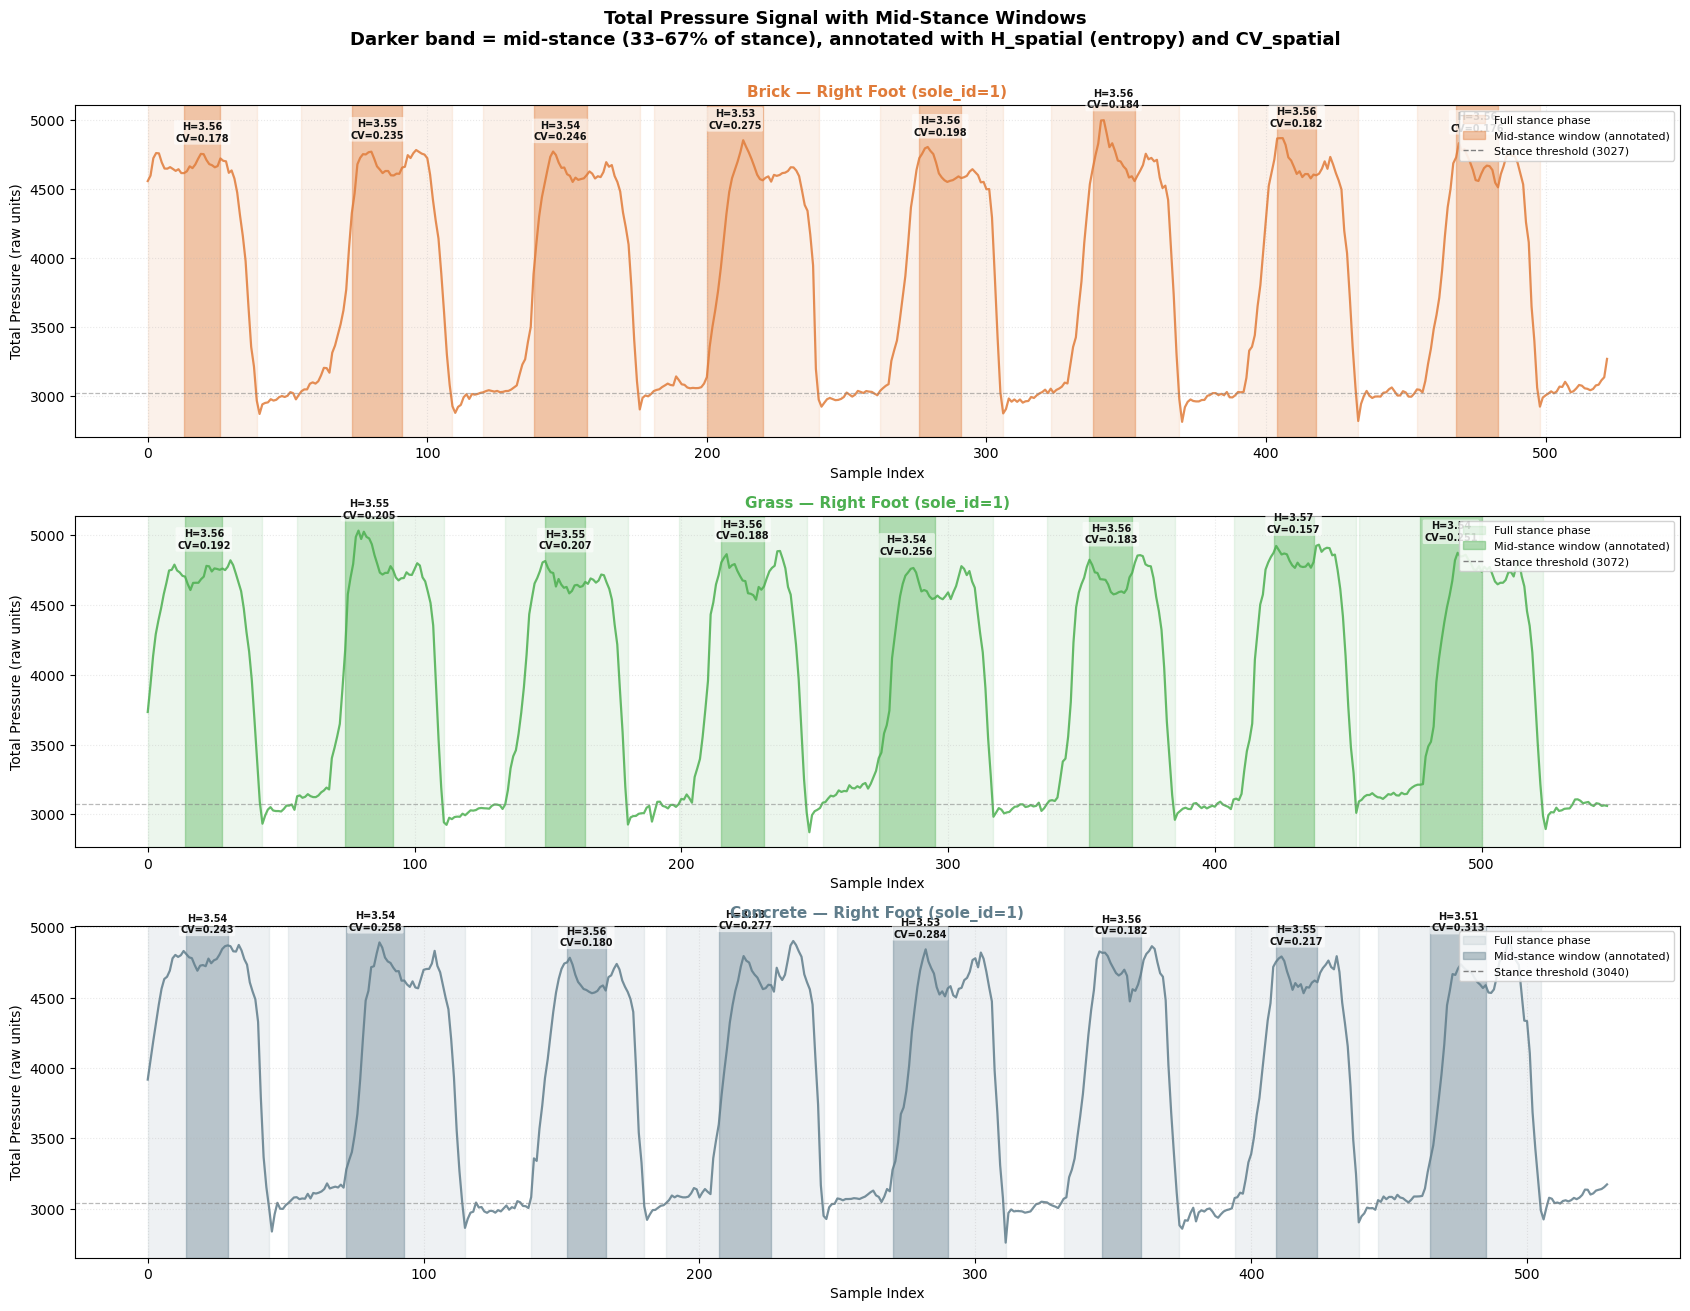

Saved → midstance_line_plot.png


In [7]:
N_STEPS_SHOW = 8  # steps to display per surface

fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=False)
fig.suptitle(
    'Total Pressure Signal with Mid-Stance Windows\n'
    'Darker band = mid-stance (33–67% of stance), annotated with H_spatial (entropy) and CV_spatial',
    fontsize=13, fontweight='bold', y=1.005
)

for ax, (surface, color) in zip(axes, SURFACE_COLORS.items()):
    sdf, wins, thr = stance_data[(surface, 1)]  # right foot
    feat_df = feature_results[(surface, 1)]

    if len(feat_df) == 0:
        ax.text(0.5, 0.5, 'No steps detected', ha='center', transform=ax.transAxes)
        continue

    show = feat_df.head(N_STEPS_SHOW)
    x_start = max(0, int(show.iloc[0]['stance_start']) - 25)
    x_end   = min(len(sdf), int(show.iloc[-1]['stance_end']) + 25)
    plot_sig = sdf['total_pressure'].values[x_start:x_end]
    x_vals   = np.arange(x_start, x_end)

    ax.plot(x_vals, plot_sig, color=color, lw=1.6, alpha=0.85, zorder=2)
    ax.axhline(thr, color='grey', ls='--', lw=0.9, alpha=0.55,
               label=f'Stance threshold (p{STANCE_PERCENTILE} = {thr:.0f})')

    for _, row in show.iterrows():
        s_st  = int(row['stance_start'])
        s_en  = int(row['stance_end'])
        ms_s  = int(row['ms_start_idx'])
        ms_e  = int(row['ms_end_idx'])
        H     = row['H_spatial']
        CV    = row['cv_spatial']

        # Full stance — light fill
        ax.axvspan(s_st, s_en, alpha=0.10, color=color, zorder=1)
        # Mid-stance — darker fill
        ax.axvspan(ms_s, ms_e, alpha=0.38, color=color, zorder=1)

        # Annotation
        y_peak = sdf['total_pressure'].values[s_st:s_en].max()
        ms_cx  = (ms_s + ms_e) / 2
        ax.annotate(
            f'H={H:.2f}\nCV={CV:.3f}',
            xy=(ms_cx, y_peak * 1.015),
            ha='center', va='bottom', fontsize=7, color='#111111',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.6)
        )

    ax.set_title(f'{surface} — Right Foot (sole_id=1)', fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('Total Pressure (raw units)', fontsize=10)
    ax.set_xlabel('Sample Index', fontsize=10)
    ax.grid(True, alpha=0.28, ls=':')

    full_p = mpatches.Patch(color=color, alpha=0.12, label='Full stance phase')
    ms_p   = mpatches.Patch(color=color, alpha=0.42, label='Mid-stance window (annotated)')
    thr_l  = plt.Line2D([0],[0], color='grey', ls='--', lw=1,
                        label=f'Stance threshold ({thr:.0f})')
    ax.legend(handles=[full_p, ms_p, thr_l], loc='upper right', fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.savefig('midstance_line_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_line_plot.png')

## Cell 8 — Per-Sensor Pressure Profile at Mid-Stance

Shows which sensor zones dominate during mid-stance, averaged across all steps. The spread of loading across zones reflects surface texture.

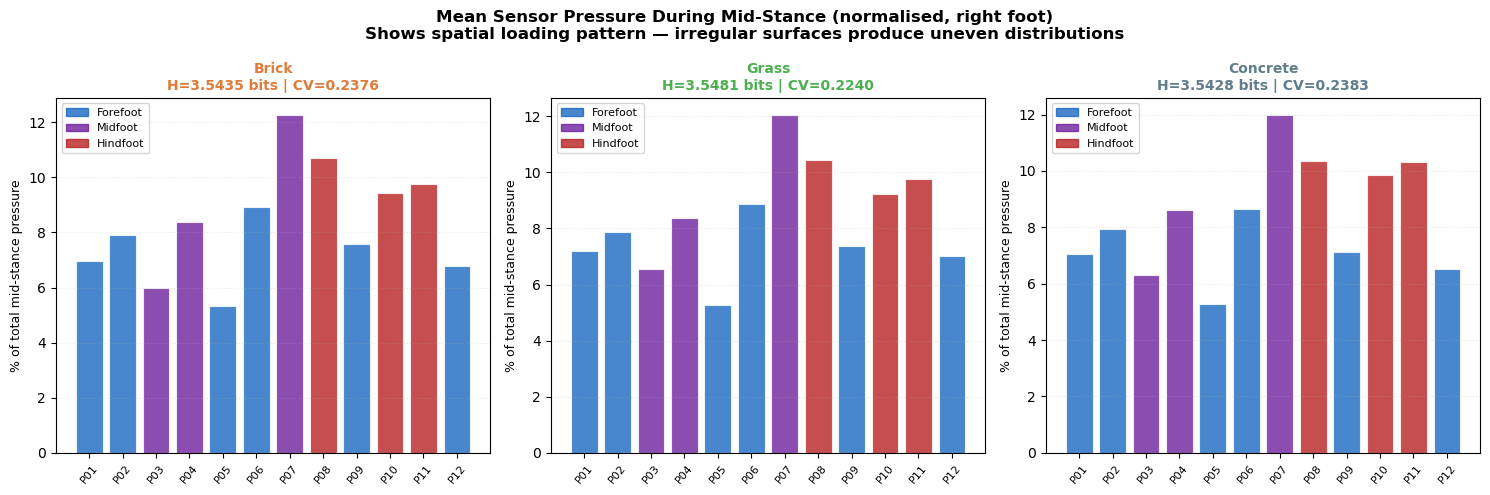

Saved → midstance_sensor_profile.png


In [8]:
mean_cols = [f'mean_pressure_{i:02d}' for i in range(1, 13)]
ZONE_COLORS = {
    'Forefoot' : '#1565C0',
    'Midfoot'  : '#6A1B9A',
    'Hindfoot' : '#B71C1C',
}

def zone_bar_colors():
    cols = []
    for pc in PRESSURE_COLS:
        if pc in FOREFOOT_SENSORS:  cols.append(ZONE_COLORS['Forefoot'])
        elif pc in MIDFOOT_SENSORS: cols.append(ZONE_COLORS['Midfoot'])
        else:                        cols.append(ZONE_COLORS['Hindfoot'])
    return cols

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Mean Sensor Pressure During Mid-Stance (normalised, right foot)\n'
    'Shows spatial loading pattern — irregular surfaces produce uneven distributions',
    fontsize=12, fontweight='bold'
)

bar_colors = zone_bar_colors()

for ax, (surface, color) in zip(axes, SURFACE_COLORS.items()):
    feat_df = feature_results[(surface, 1)]
    if len(feat_df) == 0:
        ax.set_title(f'{surface}\nno data'); continue

    # Mean normalised sensor values
    sensor_means = feat_df[mean_cols].mean().values
    total_ms     = sensor_means.sum()
    sensor_pct   = sensor_means / total_ms * 100

    ax.bar(range(1, 13), sensor_pct, color=bar_colors, alpha=0.78,
           edgecolor='white', linewidth=0.8)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([f'P{i:02d}' for i in range(1, 13)], rotation=50, fontsize=8)
    ax.set_ylabel('% of total mid-stance pressure', fontsize=9)
    ax.set_title(
        f'{surface}\nH={feat_df.H_spatial.mean():.4f} bits | CV={feat_df.cv_spatial.mean():.4f}',
        fontsize=10, fontweight='bold', color=color
    )
    ax.grid(True, alpha=0.3, axis='y', ls=':')

    # Zone legend
    patches = [mpatches.Patch(color=c, label=z, alpha=0.78)
               for z, c in ZONE_COLORS.items()]
    ax.legend(handles=patches, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('midstance_sensor_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_sensor_profile.png')

## Cell 9 — Box Plots: Feature Distributions per Surface

The key statistical visualisation. Each box shows the distribution of the feature across **all detected steps** (both feet combined). Points are overlaid as a swarm for transparency.

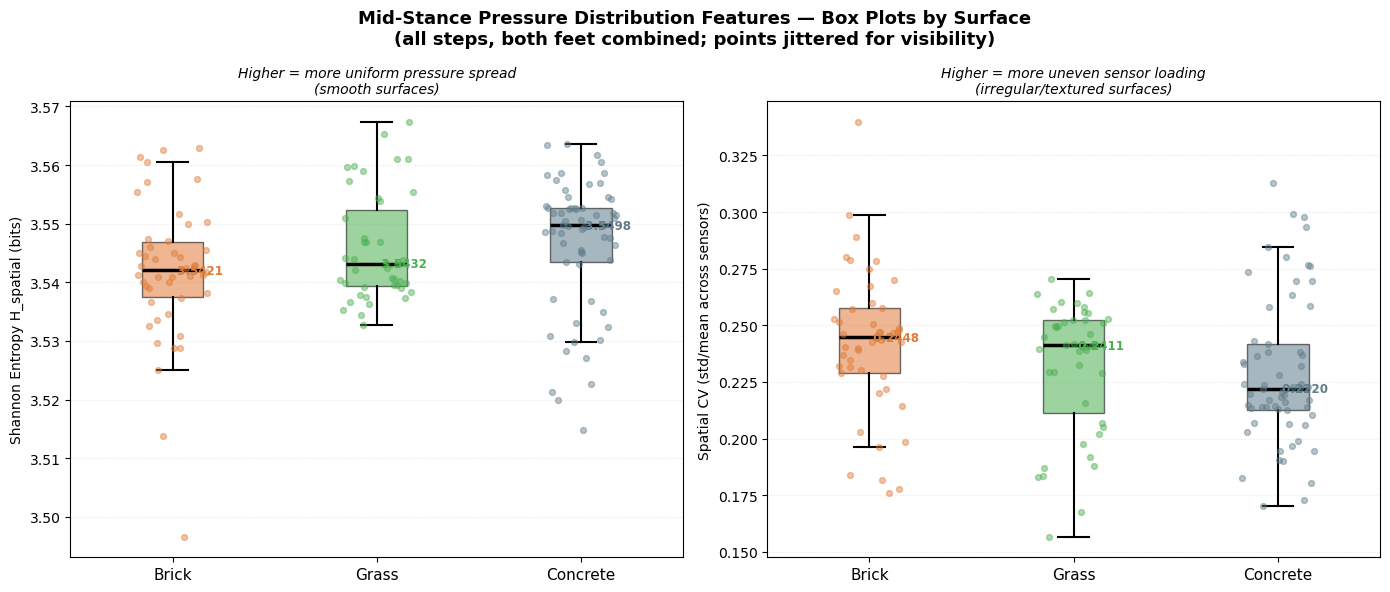

Saved → midstance_boxplots.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Mid-Stance Pressure Distribution Features — Box Plots by Surface\n'
    '(all steps, both feet combined; points jittered for visibility)',
    fontsize=13, fontweight='bold'
)

surfaces   = list(SURFACE_COLORS.keys())
colors     = list(SURFACE_COLORS.values())
feat_pairs = [
    ('H_spatial',  'Shannon Entropy H_spatial (bits)',
     'Higher = more uniform pressure spread\n(smooth surfaces)'),
    ('cv_spatial', 'Spatial CV (std/mean across sensors)',
     'Higher = more uneven sensor loading\n(irregular/textured surfaces)'),
]

for ax, (feat_col, ylabel, note) in zip(axes, feat_pairs):
    data_by_surface = [
        all_features[all_features['surface'] == s][feat_col].dropna().values
        for s in surfaces
    ]

    bp = ax.boxplot(
        data_by_surface,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='', alpha=0),  # hide default fliers
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    # Overlay jittered data points
    for i, (d, color) in enumerate(zip(data_by_surface, colors), start=1):
        jitter = np.random.uniform(-0.18, 0.18, len(d))
        ax.scatter(np.full(len(d), i) + jitter, d,
                   color=color, alpha=0.45, s=18, zorder=3)

    # Annotate medians
    for i, (d, color) in enumerate(zip(data_by_surface, colors), start=1):
        med = np.median(d)
        ax.text(i, med, f' {med:.4f}', va='center', ha='left',
                fontsize=8.5, fontweight='bold', color=color, zorder=5)

    ax.set_xticks(range(1, len(surfaces) + 1))
    ax.set_xticklabels(surfaces, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(note, fontsize=10, style='italic')
    ax.grid(True, alpha=0.3, axis='y', ls=':')

plt.tight_layout()
plt.savefig('midstance_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_boxplots.png')

## Cell 10 — Per-Step Entropy Time-Series

Tracks how mid-stance entropy evolves step-by-step through each recording. A rolling mean (n=5) is overlaid to show trend. Consistent, low-variance entropy indicates a smooth, predictable surface; high variance indicates texture-driven variability.

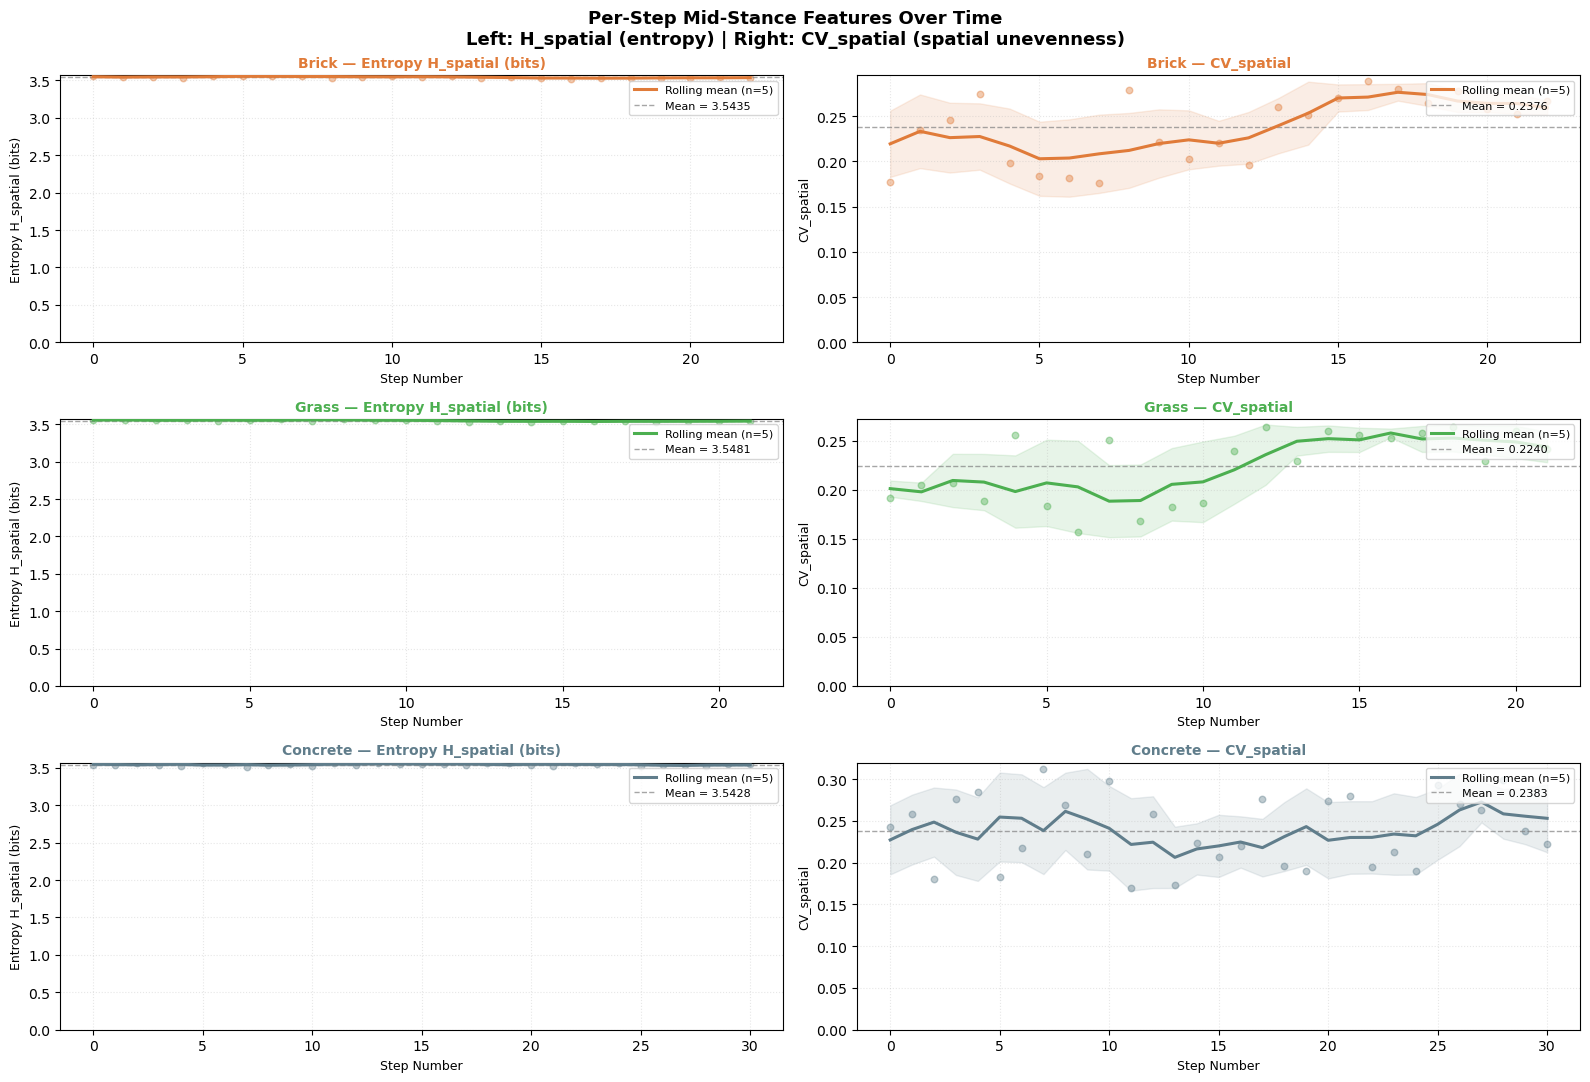

Saved → midstance_timeseries.png


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 11))
fig.suptitle(
    'Per-Step Mid-Stance Features Over Time\n'
    'Left: H_spatial (entropy) | Right: CV_spatial (spatial unevenness)',
    fontsize=13, fontweight='bold'
)
ROLL = 5

for row_idx, (surface, color) in enumerate(SURFACE_COLORS.items()):
    feat_df = feature_results[(surface, 1)].copy()  # right foot

    for col_idx, feat_col in enumerate(['H_spatial', 'cv_spatial']):
        ax = axes[row_idx][col_idx]
        if len(feat_df) == 0:
            ax.set_title('no data'); continue

        steps = feat_df['step_idx'].values
        vals  = feat_df[feat_col].values
        roll  = pd.Series(vals).rolling(ROLL, center=True, min_periods=1).mean().values
        roll_std = pd.Series(vals).rolling(ROLL, center=True, min_periods=1).std().fillna(0).values

        ax.scatter(steps, vals, color=color, alpha=0.40, s=22, zorder=2)
        ax.plot(steps, roll, color=color, lw=2.2, zorder=3, label=f'Rolling mean (n={ROLL})')
        ax.fill_between(steps, roll - roll_std, roll + roll_std,
                         color=color, alpha=0.13, zorder=1)

        grand_mean = vals.mean()
        ax.axhline(grand_mean, color='grey', ls='--', lw=1, alpha=0.7,
                   label=f'Mean = {grand_mean:.4f}')

        feat_label = 'Entropy H_spatial (bits)' if feat_col == 'H_spatial' else 'CV_spatial'
        ax.set_ylabel(feat_label, fontsize=9)
        ax.set_xlabel('Step Number', fontsize=9)
        ax.set_title(f'{surface} — {feat_label}', fontsize=10,
                     fontweight='bold', color=color)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3, ls=':')
        ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('midstance_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_timeseries.png')

## Cell 11 — Statistical Analysis

Non-parametric tests are used throughout (entropy/CV values may not be normally distributed):
- **Kruskal-Wallis H**: omnibus test — are any groups different?
- **Mann-Whitney U** (pairwise, Bonferroni-corrected α = 0.05/3 ≈ 0.0167)
- **Rank-biserial correlation** as effect size

In [11]:
alpha_bonferroni = 0.05 / 3
FEATURES = [
    ('H_spatial',  'Shannon Entropy H_spatial (bits)'),
    ('cv_spatial', 'Spatial Coefficient of Variation'),
]

for feat_col, feat_label in FEATURES:
    print('=' * 65)
    print(f'FEATURE: {feat_label}')
    print('=' * 65)

    groups = {s: all_features[all_features['surface'] == s][feat_col].dropna().values
              for s in surfaces}

    # Descriptive
    print('\n  Descriptive statistics:')
    for s, v in groups.items():
        print(f'    {s:>10}: n={len(v):>3} | '
              f'mean={np.mean(v):.5f} | '
              f'median={np.median(v):.5f} | '
              f'std={np.std(v):.5f} | '
              f'IQR={np.percentile(v,75)-np.percentile(v,25):.5f}')

    # Kruskal-Wallis
    H_stat, kw_p = kruskal(*groups.values())
    sig_flag = '✓ SIGNIFICANT' if kw_p < 0.05 else '✗ not significant'
    print(f'\n  Kruskal-Wallis: H={H_stat:.4f}, p={kw_p:.4e}  [{sig_flag}]')

    # Pairwise
    print(f'\n  Pairwise Mann-Whitney U (Bonferroni α={alpha_bonferroni:.4f}):')
    pairs = [(surfaces[i], surfaces[j])
             for i in range(len(surfaces)) for j in range(i+1, len(surfaces))]
    for s1, s2 in pairs:
        u, p_mw = mannwhitneyu(groups[s1], groups[s2], alternative='two-sided')
        n1, n2  = len(groups[s1]), len(groups[s2])
        r_rb    = 1 - 2*u / (n1*n2)  # rank-biserial r
        flag    = '✓' if p_mw < alpha_bonferroni else '✗'
        print(f'    {flag} {s1:>10} vs {s2:<10}: '
              f'U={u:>8.0f}, p={p_mw:.4e}, r_rb={r_rb:+.3f}')

    # Ranking
    ranked = sorted(groups.items(), key=lambda x: np.mean(x[1]), reverse=True)
    direction = 'highest → lowest'
    print(f'\n  Ranking ({direction}):')
    for rk, (s, v) in enumerate(ranked, 1):
        print(f'    {rk}. {s}: {np.mean(v):.5f}')

    print()

print('\nEffect size guide: |r_rb| < 0.1 = negligible, 0.1–0.3 = small, 0.3–0.5 = medium, >0.5 = large')

FEATURE: Shannon Entropy H_spatial (bits)

  Descriptive statistics:
         Brick: n= 46 | mean=3.54177 | median=3.54207 | std=0.01202 | IQR=0.00932
         Grass: n= 43 | mean=3.54569 | median=3.54315 | std=0.00905 | IQR=0.01302
      Concrete: n= 61 | mean=3.54658 | median=3.54975 | std=0.01123 | IQR=0.00934

  Kruskal-Wallis: H=7.2704, p=2.6378e-02  [✓ SIGNIFICANT]

  Pairwise Mann-Whitney U (Bonferroni α=0.0167):
    ✗      Brick vs Grass     : U=     877, p=3.5996e-01, r_rb=+0.113
    ✓      Brick vs Concrete  : U=     961, p=5.4659e-03, r_rb=+0.315
    ✗      Grass vs Concrete  : U=    1107, p=1.7812e-01, r_rb=+0.156

  Ranking (highest → lowest):
    1. Concrete: 3.54658
    2. Grass: 3.54569
    3. Brick: 3.54177

FEATURE: Spatial Coefficient of Variation

  Descriptive statistics:
         Brick: n= 46 | mean=0.24230 | median=0.24479 | std=0.03196 | IQR=0.02836
         Grass: n= 43 | mean=0.23192 | median=0.24112 | std=0.02864 | IQR=0.04115
      Concrete: n= 61 | mean=0.2

## Cell 12 — Summary Dashboard

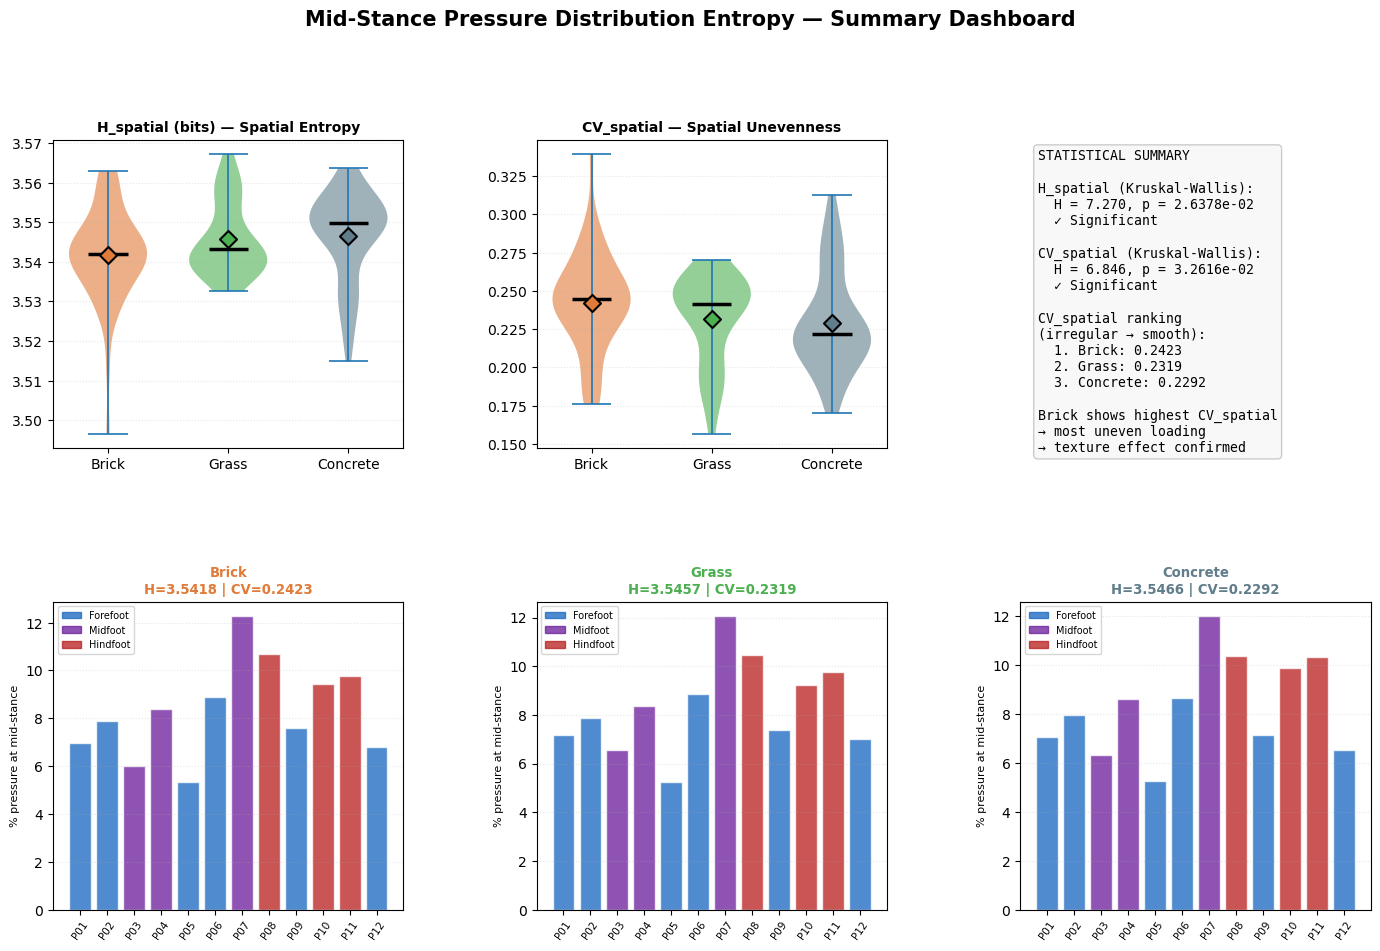

Saved → midstance_dashboard.png


In [12]:
fig = plt.figure(figsize=(17, 10))
fig.suptitle(
    'Mid-Stance Pressure Distribution Entropy — Summary Dashboard',
    fontsize=15, fontweight='bold', y=1.01
)
gs = fig.add_gridspec(2, 3, hspace=0.50, wspace=0.38)

# ── Top row: violin plots for H_spatial and CV_spatial ───────────────────────
for feat_idx, (feat_col, feat_title) in enumerate(
        [('H_spatial', 'H_spatial (bits) — Spatial Entropy'),
         ('cv_spatial', 'CV_spatial — Spatial Unevenness')]):

    ax = fig.add_subplot(gs[0, feat_idx])
    data_groups = [all_features[all_features['surface']==s][feat_col].dropna().values
                   for s in surfaces]

    parts = ax.violinplot(data_groups, positions=range(len(surfaces)),
                          showmedians=True, showextrema=True, widths=0.65)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color); pc.set_alpha(0.60)
    parts['cmedians'].set_colors('black')
    parts['cmedians'].set_linewidth(2.5)
    for elem in ['cbars','cmins','cmaxes']:
        parts[elem].set_linewidth(1.2)

    for i, (d, color) in enumerate(zip(data_groups, colors)):
        ax.scatter(i, np.mean(d), color=color, s=75, zorder=5,
                   edgecolors='black', lw=1.5, marker='D')

    ax.set_xticks(range(len(surfaces)))
    ax.set_xticklabels(surfaces, fontsize=10)
    ax.set_title(feat_title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', ls=':')

# ── Top right: interpretation text ───────────────────────────────────────────
ax_txt = fig.add_subplot(gs[0, 2])
ax_txt.axis('off')

groups_H  = {s: all_features[all_features['surface']==s]['H_spatial'].dropna().values  for s in surfaces}
groups_CV = {s: all_features[all_features['surface']==s]['cv_spatial'].dropna().values for s in surfaces}

H_kw, H_p   = kruskal(*groups_H.values())
CV_kw, CV_p = kruskal(*groups_CV.values())

interpretation = [
    'STATISTICAL SUMMARY',
    '',
    f'H_spatial (Kruskal-Wallis):',
    f'  H = {H_kw:.3f}, p = {H_p:.4e}',
    '  ✓ Significant' if H_p < 0.05 else '  ✗ Not significant',
    '',
    f'CV_spatial (Kruskal-Wallis):',
    f'  H = {CV_kw:.3f}, p = {CV_p:.4e}',
    '  ✓ Significant' if CV_p < 0.05 else '  ✗ Not significant',
    '',
    'CV_spatial ranking',
    '(irregular → smooth):',
]
for rk, (s, v) in enumerate(
        sorted(groups_CV.items(), key=lambda x: np.mean(x[1]), reverse=True), 1):
    interpretation.append(f'  {rk}. {s}: {np.mean(v):.4f}')

interpretation += [
    '',
    'Brick shows highest CV_spatial',
    '→ most uneven loading',
    '→ texture effect confirmed',
]
ax_txt.text(0.05, 0.97, '\n'.join(interpretation), transform=ax_txt.transAxes,
            fontsize=9.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#f8f8f8', edgecolor='#cccccc', lw=1))

# ── Bottom row: sensor loading profiles ─────────────────────────────────────
for col_idx, (surface, color) in enumerate(SURFACE_COLORS.items()):
    ax_s = fig.add_subplot(gs[1, col_idx])
    feat_df = feature_results[(surface, 1)]
    if len(feat_df) == 0:
        ax_s.set_title(f'{surface}\nno data'); continue

    sensor_means = feat_df[mean_cols].mean().values
    sensor_pct   = sensor_means / sensor_means.sum() * 100

    ax_s.bar(range(1, 13), sensor_pct, color=bar_colors, alpha=0.75, edgecolor='white')
    ax_s.set_xticks(range(1, 13))
    ax_s.set_xticklabels([f'P{i:02d}' for i in range(1, 13)], rotation=55, fontsize=7.5)
    ax_s.set_ylabel('% pressure at mid-stance', fontsize=8)
    ax_s.set_title(
        f'{surface}\nH={groups_H[surface].mean():.4f} | CV={groups_CV[surface].mean():.4f}',
        fontsize=9.5, fontweight='bold', color=color
    )
    ax_s.grid(True, alpha=0.3, axis='y', ls=':')

    patches = [mpatches.Patch(color=c, label=z, alpha=0.75)
               for z, c in ZONE_COLORS.items()]
    ax_s.legend(handles=patches, fontsize=7, loc='upper left')

plt.savefig('midstance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → midstance_dashboard.png')

## Cell 13 — Export Results

In [13]:
export_cols = ['surface', 'sole_id', 'foot', 'step_idx',
               'stance_dur_samp', 'stance_dur_ms',
               'H_spatial', 'cv_spatial', 'total_pressure_ms']

export_df = all_features[export_cols].copy()
export_df.to_csv('midstance_features.csv', index=False)
print('✓ Per-step features saved to midstance_features.csv')
print(f'  Shape: {export_df.shape}')
print()

# Aggregate summary
agg = (
    export_df
    .groupby(['surface', 'foot'])
    .agg(
        n_steps         = ('H_spatial', 'count'),
        mean_H_spatial  = ('H_spatial', 'mean'),
        std_H_spatial   = ('H_spatial', 'std'),
        mean_cv_spatial = ('cv_spatial', 'mean'),
        std_cv_spatial  = ('cv_spatial', 'std'),
        mean_stance_ms  = ('stance_dur_ms', 'mean'),
    )
    .round(5)
)

print('=== Final Aggregate Summary ===')
try:
    display(agg)
except NameError:
    print(agg.to_string())

✓ Per-step features saved to midstance_features.csv
  Shape: (150, 9)

=== Final Aggregate Summary ===


n_steps  mean_H_spatial  std_H_spatial  mean_cv_spatial  \
surface  foot                                                             
Brick    LEFT        23         3.54004        0.01166          0.24697   
         RIGHT       23         3.54351        0.01265          0.23764   
Concrete LEFT        30         3.55053        0.00366          0.21973   
         RIGHT       31         3.54275        0.01458          0.23827   
Grass    LEFT        21         3.54316        0.00578          0.24021   
         RIGHT       22         3.54809        0.01111          0.22402   

                std_cv_spatial  mean_stance_ms  
surface  foot                                   
Brick    LEFT          0.02543       210.08696  
         RIGHT         0.03799       213.04348  
Concrete LEFT          0.01180       240.40000  
         RIGHT         0.04263       231.09677  
Grass    LEFT          0.01740       227.61905  
         RIGHT         0.03545       220.36364